In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("/Users/nishantsoni/Desktop/personal/ML project/hands on projects by me/supervised learning/classification/porject_1_heart_disease/heart-disease.csv")
df.shape

(303, 14)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

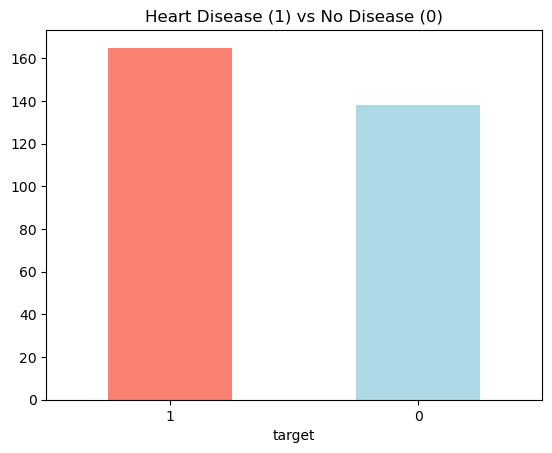

In [8]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"])
plt.title("Heart Disease (1) vs No Disease (0)")
plt.xticks(rotation=0);

In [9]:
df.corr()["target"].sort_values(ascending=False)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64

In [10]:
X = df.drop("target", axis=1)   # everything EXCEPT the answer
y = df["target"]                # just the answer
X.shape, y.shape

((303, 13), (303,))

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((242, 13), (61, 13))

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [14]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":            XGBClassifier(random_state=42),
    "CatBoost":           CatBoostClassifier(random_state=42, verbose=0),
    "NaiveBayes":         GaussianNB(),
}

In [15]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)                    # train on training data
    results[name] = model.score(X_test, y_test)    # accuracy on unseen test data
results

{'LogisticRegression': 0.8032786885245902,
 'KNN': 0.5901639344262295,
 'SVM': 0.6557377049180327,
 'DecisionTree': 0.7049180327868853,
 'RandomForest': 0.8360655737704918,
 'GradientBoosting': 0.819672131147541,
 'XGBoost': 0.8032786885245902,
 'CatBoost': 0.8032786885245902,
 'NaiveBayes': 0.819672131147541}

In [16]:
results_df = pd.DataFrame(results, index=["accuracy"]).T
results_df.sort_values("accuracy", ascending=False)

,accuracy
RandomForest,0.836066
GradientBoosting,0.819672
NaiveBayes,0.819672
LogisticRegression,0.803279
XGBoost,0.803279
CatBoost,0.803279
DecisionTree,0.704918
SVM,0.655738
KNN,0.590164


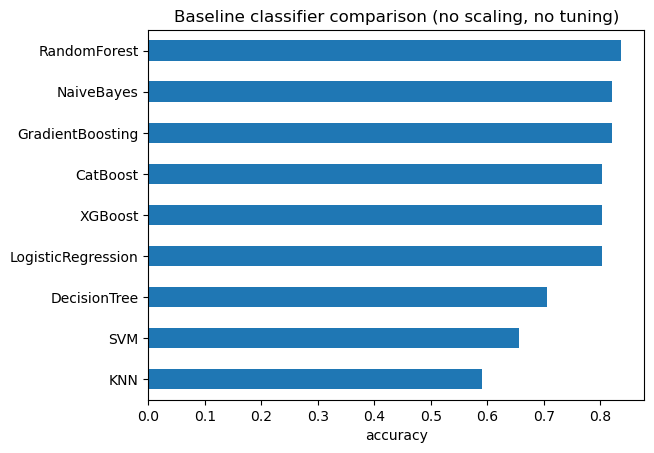

In [17]:
results_df.sort_values("accuracy").plot(kind="barh", legend=False)
plt.xlabel("accuracy")
plt.title("Baseline classifier comparison (no scaling, no tuning)");

In [21]:
## why LogisticRegression and xgboost and cat boost have same value

# Great observation — and it's exactly the kind of thing worth stopping on. The short answer: it's a coincidence forced by your tiny test set, not because the models are doing the same thing.
# Here's the key: your test set has only 61 patients. So accuracy can only land on discrete steps of 1/61 ≈ 0.0164. Every model's accuracy must be one of 0/61, 1/61, 2/61, … 61/61. Do the math on your numbers:

# 0.8032786885245902 × 61 = 49 → LogReg, XGBoost, and CatBoost each got 49 out of 61 correct.
# 0.819672131147541 × 61 = 50 → GradientBoosting and NaiveBayes each got 50 out of 61 correct.

# With only ~62 possible accuracy values to land on, it's actually common for different models to tie. They're not identical — they just happened to get the same number right.
# And here's the important nuance: same accuracy does not mean same predictions. LogReg, XGBoost, and CatBoost could each be getting a different 49 patients right — agreeing on most but disagreeing on which specific ones they miss. Accuracy throws away all that detail and collapses it to one fraction.
# You can prove this to yourself. Add a chunk:

In [18]:
lr  = LogisticRegression(max_iter=1000).fit(X_train, y_train)
xgb = XGBClassifier(random_state=42).fit(X_train, y_train)

lr_pred  = lr.predict(X_test)
xgb_pred = xgb.predict(X_test)

# how many of the 61 predictions are identical?
(lr_pred == xgb_pred).sum(), len(y_test)

(55, 61)

In [19]:
lr.predict_proba(X_test)[:5].round(3)

array([[0.898, 0.102],
       [0.816, 0.184],
       [0.993, 0.007],
       [0.284, 0.716],
       [0.314, 0.686]])

In [20]:
xgb.predict_proba(X_test)[:5].round(3)

array([[0.981, 0.019],
       [0.301, 0.699],
       [1.   , 0.   ],
       [0.023, 0.977],
       [0.128, 0.872]], dtype=float32)

In [22]:
# Now the two upgrades that fix what we saw: scaling (to rescue KNN and SVM) and cross-validation (to break those ties and give a trustworthy ranking). We'll do scaling the right way — inside a Pipeline — so it ties straight into your notes.
# Chunk 24 — prove that scaling rescues KNN
# First, see the effect directly. We compare unscaled KNN (what you had) with a scaled version. make_pipeline bundles the scaler and model into one object so the scaling happens automatically and leak-free.

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

knn_raw = KNeighborsClassifier().fit(X_train, y_train)
print("KNN unscaled:", round(knn_raw.score(X_test, y_test), 4))

knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier()).fit(X_train, y_train)
print("KNN scaled  :", round(knn_scaled.score(X_test, y_test), 4))

## You should see a clear jump — same model, same data, just put on a fair scale.

KNN unscaled: 0.5902
KNN scaled  : 0.8033


In [24]:
# Chunk 25 — same story for SVM
svm_raw = SVC().fit(X_train, y_train)
print("SVM unscaled:", round(svm_raw.score(X_test, y_test), 4))

svm_scaled = make_pipeline(StandardScaler(), SVC()).fit(X_train, y_train)
print("SVM scaled  :", round(svm_scaled.score(X_test, y_test), 4))

# SVM usually jumps the most — its previous weak score was entirely a scaling problem, not the model's fault. This is the lesson to lock in: a bad score often means wrong preparation, not a bad model.


SVM unscaled: 0.6557
SVM scaled  : 0.8197


In [25]:
# Chunk 26 — rebuild the dictionary, scaling only the models that need it
# The three distance/linear models get wrapped in a scaling pipeline; the tree-based models stay raw because scaling does nothing for them (they only care about value order, not magnitude).
models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN":                make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "SVM":                make_pipeline(StandardScaler(), SVC()),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":            XGBClassifier(random_state=42),
    "CatBoost":           CatBoostClassifier(random_state=42, verbose=0),
    "NaiveBayes":         GaussianNB(),
}

In [26]:
# Chunk 27 — cross-validation instead of one split
# This is the big one. Instead of scoring on a single 61-patient test set, cross_val_score splits the data into 5 folds and scores on each in turn, then we average. Because each model is refit inside every fold, the scaler in those pipelines only ever learns from that fold's training portion — no leakage. That's exactly why we wrapped scaling in a Pipeline rather than scaling the data by hand.
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_results[name] = scores.mean()
    print(f"{name:20s}: {scores.mean():.4f}  (+/- {scores.std():.4f})")

LogisticRegression  : 0.8416  (+/- 0.0448)
KNN                 : 0.7985  (+/- 0.0714)
SVM                 : 0.8217  (+/- 0.0534)
DecisionTree        : 0.7289  (+/- 0.0655)
RandomForest        : 0.8152  (+/- 0.0334)
GradientBoosting    : 0.8087  (+/- 0.0513)
XGBoost             : 0.7856  (+/- 0.0335)
CatBoost            : 0.8118  (+/- 0.0527)
NaiveBayes          : 0.8084  (+/- 0.0697)


In [27]:
# Chunk 28 — sorted results table
cv_df = pd.DataFrame(cv_results, index=["cv_accuracy"]).T
cv_df.sort_values("cv_accuracy", ascending=False)

,cv_accuracy
LogisticRegression,0.841585
SVM,0.821749
RandomForest,0.815191
CatBoost,0.811803
GradientBoosting,0.808689
NaiveBayes,0.808415
KNN,0.798470
XGBoost,0.785628
DecisionTree,0.728852


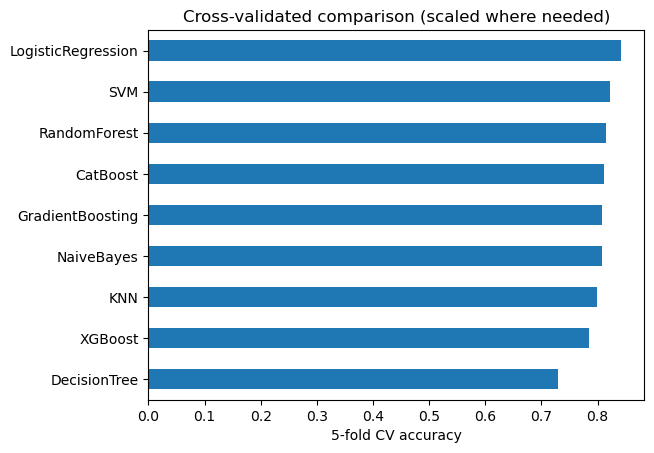

In [28]:
## Chunk 29 — plot the trustworthy ranking
cv_df.sort_values("cv_accuracy").plot(kind="barh", legend=False)
plt.xlabel("5-fold CV accuracy")
plt.title("Cross-validated comparison (scaled where needed)");

In [ ]:
# ## question - when we should use 'train_test_split' and 'cross_val_score'?
# Synthesized conceptual distinction and crafted practical tuning demonstrationExcellent question — this trips up a lot of people, and getting it straight will make you noticeably better than someone who just copies code. Let me answer it, then we'll start tuning (which uses both).
# When to use train_test_split vs cross_val_score
# They're not either/or — they do different jobs, and the professional pattern uses them together.
# train_test_split makes one split: it carves off a held-out test set you don't touch until the very end. Simple and fast, but the score depends on which rows happened to land in test. On small data that's unreliable — you saw it yourself: three models tied at exactly 0.8033 because the 61-patient test set is so coarse.
# cross_val_score rotates the split: every row gets to be in the validation fold once, and you average the k scores. That gives a much more stable estimate (plus a std telling you how stable), and it uses all the data for both training and validation. But by itself it doesn't leave you a single untouched "final exam" set.
# The pattern that uses both correctly:

# train_test_split first → lock away a final test set. Don't touch it.
# cross_val_score (or CV inside GridSearchCV) on the training part → compare models and tune hyperparameters. All your decisions happen here.
# Score the chosen, tuned model once on the held-out test set → your honest final number.

# A quick decision guide:
# Use train_test_splitUse cross_val_scoreFinal hold-out for the last honest checkComparing models / tuning hyperparametersBig data (one split is already reliable)Small data (one split is unreliable — our case)Slow models / deep learning (CV too expensive)You want a stable estimate + uncertainty (std)
# For your heart-disease project: only 303 rows, so cross-validation is the trustworthy way to compare and tune — which is exactly why the ties resolved when we switched to it. We'll still use the held-out test set (X_test) for the final number once a model is tuned. That's what the next chunks demonstrat

In [29]:
# Tuning — Part 1: by hand, then automated
# Now your favorite part. We tune on the training data with CV, keeping X_test untouched for the final check — literally the pattern from the question above.
# Chunk 30 — tune KNN's n_neighbors by hand
# The clearest way to see what tuning is: try every k and CV-score each. (We score on X_train only — the test set stays sealed.)

neighbors = range(1, 21)
knn_scores = []

for k in neighbors:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    score = cross_val_score(knn, X_train, y_train, cv=cv, scoring="accuracy").mean()
    knn_scores.append(score)

knn_scores

[0.7607142857142857,
 0.8058673469387756,
 0.7935374149659864,
 0.8058673469387756,
 0.801530612244898,
 0.7973639455782313,
 0.8055272108843538,
 0.8096938775510203,
 0.8097789115646259,
 0.8055272108843538,
 0.8177721088435375,
 0.8178571428571428,
 0.8343537414965987,
 0.8343537414965987,
 0.8302721088435374,
 0.8261054421768707,
 0.8176870748299321,
 0.8218537414965986,
 0.8219387755102041,
 0.8178571428571428]

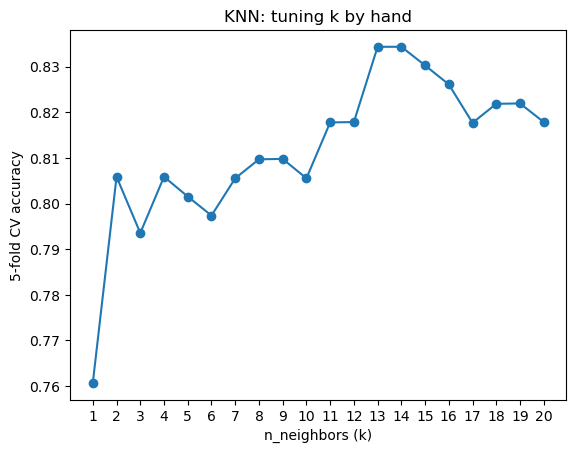

In [30]:
## Chunk 31 — plot the k curve
plt.plot(neighbors, knn_scores, marker="o")
plt.xlabel("n_neighbors (k)")
plt.ylabel("5-fold CV accuracy")
plt.title("KNN: tuning k by hand")
plt.xticks(neighbors);

In [31]:
## Chunk 32 — grab the best k
best_k = neighbors[np.argmax(knn_scores)]
print("Best k:", best_k, "| CV accuracy:", round(max(knn_scores), 4))

# That's the whole idea of tuning: search hyperparameter values for the best CV score. 
# By-hand works for one knob — but most models have several, and trying all combos by hand is hopeless. 
# That's what RandomizedSearchCV automates.

Best k: 13 | CV accuracy: 0.8344


In [32]:
# Chunk 33 — RandomizedSearchCV on RandomForest
# RandomForest has many knobs. Instead of looping by hand, we define ranges and let it sample n_iter random combinations, CV-scoring each.
from sklearn.model_selection import RandomizedSearchCV

rf_grid = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", None],
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid, n_iter=20, cv=cv, scoring="accuracy",
    random_state=42, n_jobs=-1)

rs_rf.fit(X_train, y_train)   # tune on TRAINING data; CV happens inside

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [35]:
# Chunk 34 — see what it found
print(rs_rf.best_params_)
round(rs_rf.best_score_, 4)   # best mean CV accuracy across the training folds

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}


0.8139

In [36]:
# Chunk 35 — the final honest score on the untouched test set
round(rs_rf.score(X_test, y_test), 4)   # the ONE time we use X_test

0.8197

In [38]:
# Tuning — Part 2: GridSearchCV (zoom in)
# The strategy from your notes: RandomizedSearchCV found a good region; GridSearchCV now searches exhaustively 
# in a tight grid around those winning values to squeeze out a bit more.
# Chunk 36 — focused grid around the best params

from sklearn.model_selection import GridSearchCV

rf_grid2 = {
    "n_estimators":      [200, 300, 400],   # around 300
    "min_samples_split": [8, 10, 12],       # around 10
    "min_samples_leaf":  [3, 4, 5],          # around 4
    "max_features":      ["log2", "sqrt"],
    "max_depth":         [None, 10],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid2, cv=cv, scoring="accuracy", n_jobs=-1)

gs_rf.fit(X_train, y_train)

# Notice the values are centered on what RandomizedSearch found. 
# This is 108 combos × 5 folds = 540 fits, so it'll take a few seconds. 
# (Unlike RandomizedSearch, GridSearch tries every combination — fine for a small focused grid, impossible for a huge one.)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [3, 4, ...], 'min_samples_split': [8, 10, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,400


In [39]:
gs_rf.best_params_


{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 5,
 'min_samples_split': 12,
 'n_estimators': 400}

In [40]:
round(gs_rf.best_score_, 4)

0.8221

In [42]:
# Chunk 38 — final test score of the refined model
round(gs_rf.score(X_test, y_test), 4)

0.8033

In [43]:
# Don't be surprised if GridSearch barely beats — or even ties — RandomizedSearch here. That's a genuine lesson, 
# not a failure: on a small, clean dataset like this (303 rows), models hit a performance ceiling quickly, and 
# tuning gives diminishing returns. Knowing when you're near the ceiling (and to stop fiddling) is a real skill. 
# Whichever of the two scored highest is your champion — we'll evaluate gs_rf below (swap in rs_rf if it won).

# Evaluation — the full picture (beyond accuracy)
# Accuracy alone hides what kind of mistakes the model makes. For a disease detector, that matters enormously.
# Chunk 39 — predictions from the champion

y_pred = gs_rf.predict(X_test)
y_pred[:15]

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1])

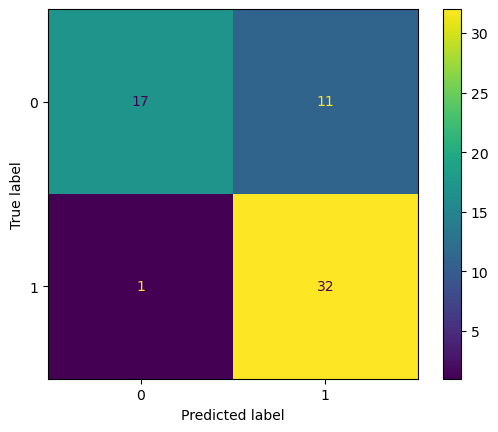

In [44]:
# Chunk 40 — confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(gs_rf, X_test, y_test);
# Read it as a 2×2: top-left and bottom-right are correct; the off-diagonal are the two error types. 
# The bottom-left (false negatives — patients with disease the model said are healthy) is the dangerous one in medicine.

In [45]:
# Chunk 41 — precision, recall, F1 per class
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# For class 1 (has disease): precision = of those flagged as sick, how many really are; recall = of all truly sick patients, 
# how many we caught. In a screening context you usually care most about recall for class 1 — missing a sick patient (low recall) is 
# worse than a false alarm.

              precision    recall  f1-score   support

           0       0.94      0.61      0.74        28
           1       0.74      0.97      0.84        33

    accuracy                           0.80        61
   macro avg       0.84      0.79      0.79        61
weighted avg       0.84      0.80      0.79        61



In [46]:
# Chunk 42 — pull the key metrics out individually
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))

# These are the numbers you'd report. If recall is lower than you'd like for a medical use case, that's a signal to later adjust 
# the decision threshold — a topic for a future project.

Precision: 0.7442
Recall   : 0.9697
F1       : 0.8421


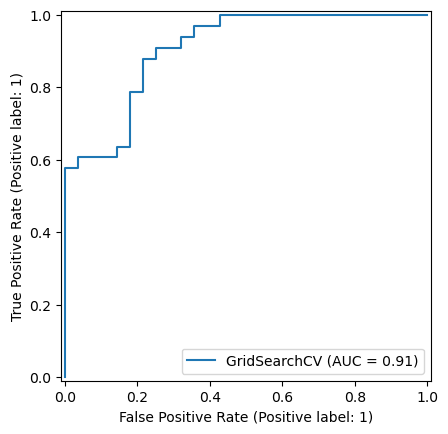

In [48]:
# Chunk 43 — ROC curve and AUC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(gs_rf, X_test, y_test);
# The ROC curve shows the trade-off between catching true positives and raising false alarms across all thresholds; 
# AUC (shown in the legend) summarizes it — 1.0 is perfect, 0.5 is random guessing. AUC is threshold-independent, 
# so it's a fairer single number than accuracy.


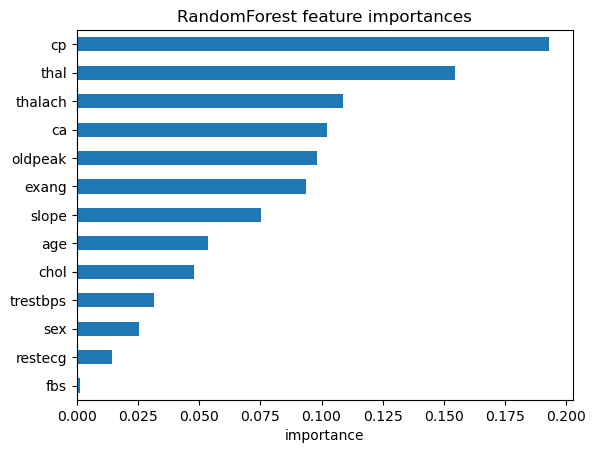

In [49]:
# Chunk 44 — which features drove the predictions?
importances = pd.Series(
    gs_rf.best_estimator_.feature_importances_, index=X.columns
).sort_values()

importances.plot(kind="barh")
plt.xlabel("importance")
plt.title("RandomForest feature importances");

# Compare this to the correlations you computed back in Chunk 9 — features like cp (chest pain), thalach (max heart rate), ca, 
# and oldpeak should rank high in both. When the model's "reasoning" lines up with the exploratory stats, that's a good sanity 
# check that it learned something real, not noise.

In [50]:
# That completes a full end-to-end classification project — load, explore, split, compare 9 models, scale, cross-validate, 
# tune two ways, and evaluate properly. The single best way to cement it now is to repeat the whole arc on a new dataset 
# (different shape, maybe with missing values or text columns, so the preprocessing muscles get worked). 





In [ ]:
# That is a genuinely sharp catch — and you're completely right. According to the cross-validated comparison, LogisticRegression 
# is your best model (~0.84), and RandomForest is only third. So your instinct is correct: methodologically, you tune the model 
# that's actually winning, not a lower one.

# Let me be honest about why we went to RandomForest first: I used it as the teaching example for RandomizedSearchCV, because RF has 
# many hyperparameters (n_estimators, max_depth, min_samples_leaf, max_features…), which is exactly the situation random search is 
# designed for. LogisticRegression has only a few knobs, so it's not a good demo for random search. But for the real decision, 
# you're right — we should tune the leader. Good scientific thinking.

# There's also a second lesson hiding in your own numbers. Look at RandomForest:
# RandomizedSearch → CV 0.8139, test 0.8197
# GridSearch → CV 0.8221 (higher!), but test 0.8033 (lower!)

# The model with the higher CV score got the lower test score. That's not a bug — it's the noise of a 61-patient test set again. 
# A 0.01–0.02 difference here is within the margin of luck, so don't over-trust tiny gaps. This is why we lean on CV and don't 
# obsess over the last decimal.

# So let's now tune the actual champion. Since LogReg has a small hyperparameter space, GridSearchCV is the right tool 
# (search it exhaustively — no need for random sampling). 
# This also reinforces the rule: small space → GridSearch, large space → RandomizedSearch.

In [51]:
# Chunk 45 — tune LogisticRegression (the real leader)


from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000)),
])

logreg_grid = {
    "model__C":       [0.01, 0.1, 1, 10, 100],   # inverse regularization strength
    "model__penalty": ["l1", "l2"],               # l1 = sparse, l2 = smooth shrinkage
    "model__solver":  ["liblinear"],              # supports BOTH l1 and l2
}

gs_lr = GridSearchCV(logreg_pipe, logreg_grid, cv=cv, scoring="accuracy", n_jobs=-1)
gs_lr.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [52]:
# Chunk 46 — best params and CV score
gs_lr.best_params_

{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

In [53]:
round(gs_lr.best_score_, 4)

0.8299

In [54]:
# Chunk 47 — test score
round(gs_lr.score(X_test, y_test), 4)

0.7869

In [55]:
# Chunk 48 — full metrics, to compare head-to-head with RF
y_pred_lr = gs_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



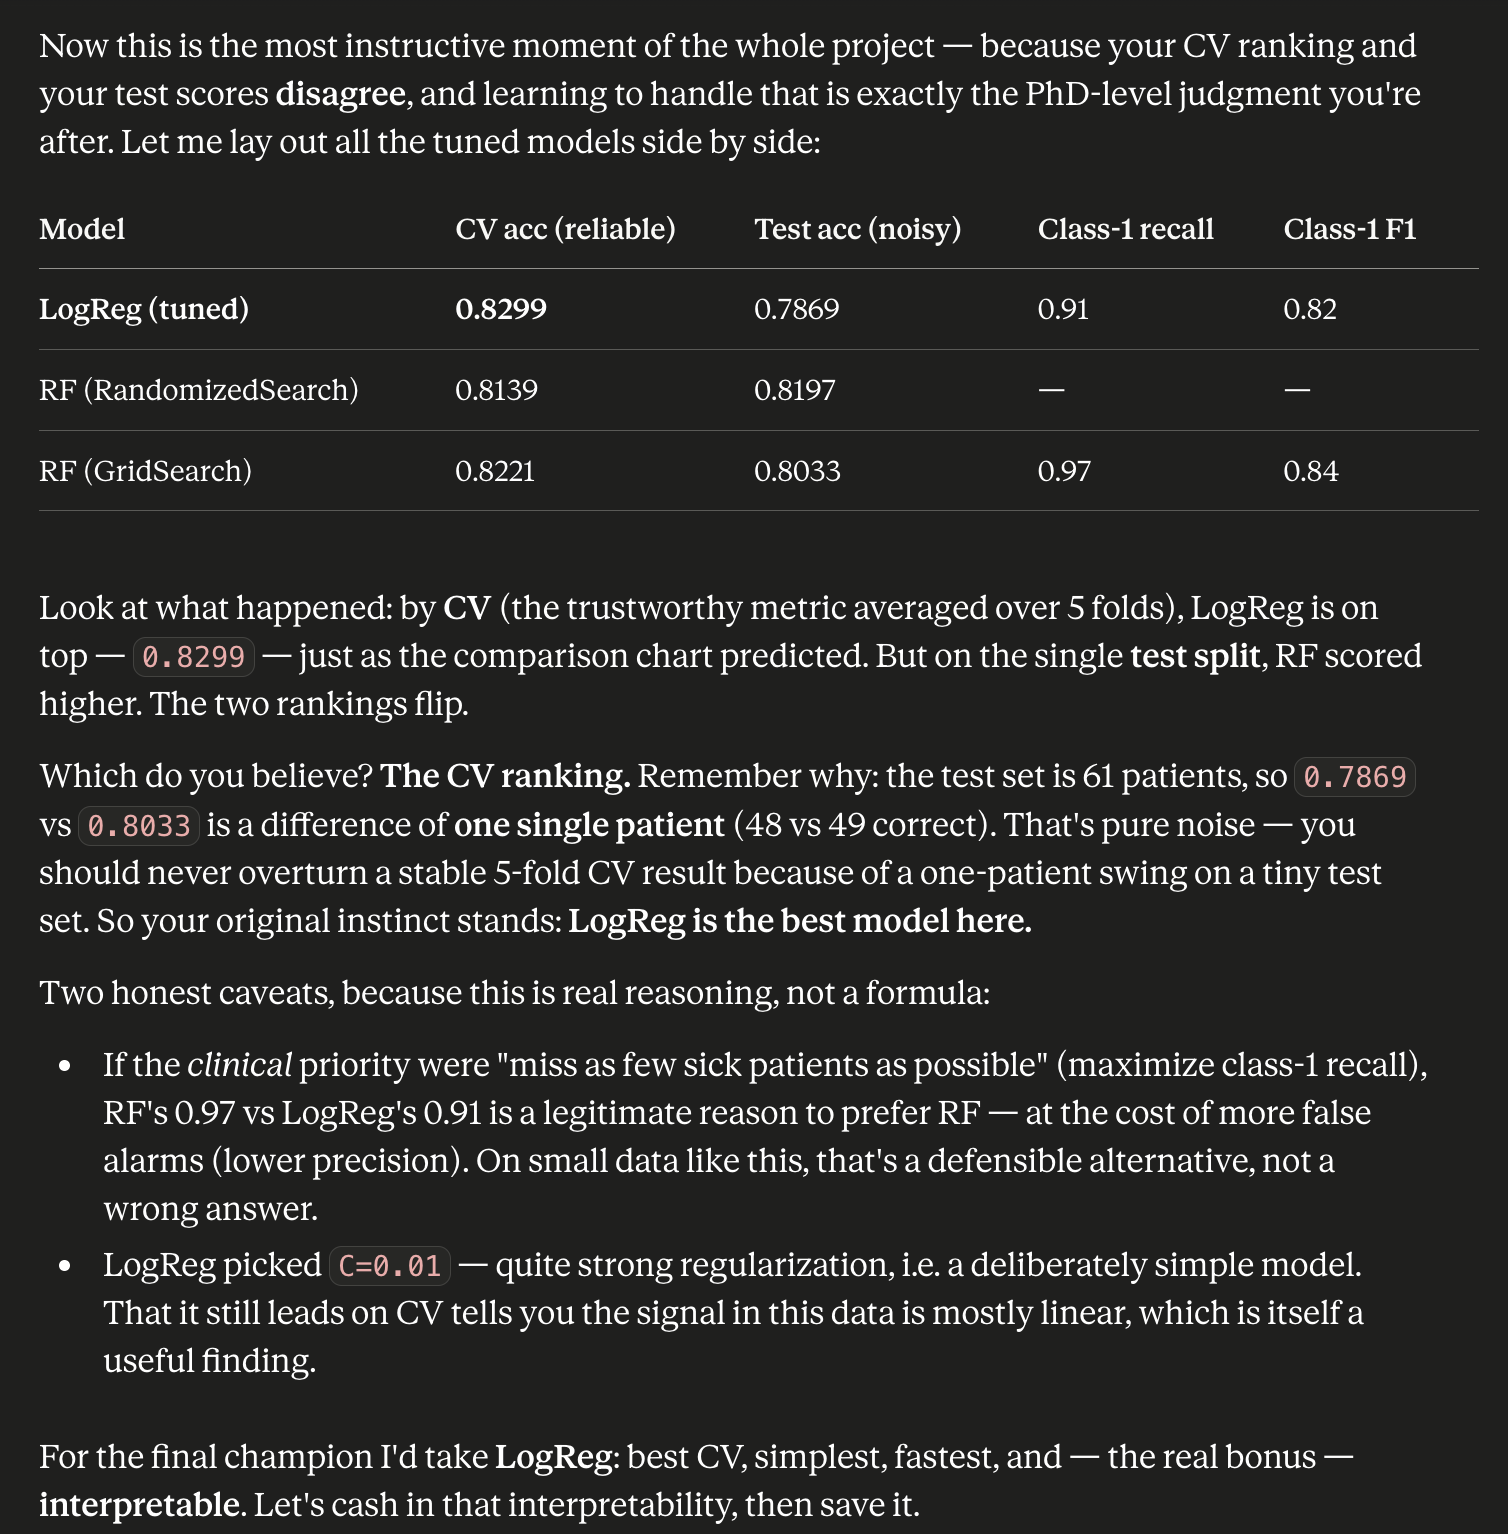


In [57]:
## Chunk 49 — read the LogReg coefficients (the interpretability payoff)
best_lr = gs_lr.best_estimator_.named_steps["model"]   # pull model out of the pipeline
coefs = pd.Series(best_lr.coef_[0], index=X.columns).sort_values()
coefs

# A positive coefficient pushes toward disease (class 1), negative pushes toward healthy. 
# Compare the signs to the correlations you computed in Chunk 9 — cp, thalach positive; ca, oldpeak, exang negative. 
# When the model's coefficients agree with the raw stats, that's strong evidence it learned real biology, not noise. 
# (This is something RF's feature importances can't give you — they show which features matter but not the direction.)

exang      -0.217101
oldpeak    -0.209106
thal       -0.207127
ca         -0.184061
sex        -0.155812
chol       -0.078399
age        -0.072478
trestbps   -0.057148
fbs        -0.010103
restecg     0.069241
slope       0.168685
thalach     0.187271
cp          0.272284
dtype: float64

In [58]:
# Chunk 50 — save the champion (the whole pipeline)
import joblib
joblib.dump(gs_lr.best_estimator_, "heart_disease_logreg.joblib")

# We save best_estimator_ — the full pipeline including the scaler — so new data gets the exact same preprocessing automatically.

['heart_disease_logreg.joblib']

In [60]:
# Chunk 51 — reload and score a brand-new patient
loaded = joblib.load("heart_disease_logreg.joblib")

new_patient = pd.DataFrame([{
    "age": 54, "sex": 1, "cp": 0, "trestbps": 130, "chol": 250,
    "fbs": 0, "restecg": 1, "thalach": 150, "exang": 0, "oldpeak": 1.5,
    "slope": 2, "ca": 0, "thal": 2,
}])

print("Prediction:", loaded.predict(new_patient))            # 0 = no disease, 1 = disease
print("Probability:", loaded.predict_proba(new_patient).round(3))

# This completes the full lifecycle: the saved pipeline takes raw patient values, scales them, and returns a prediction with a 
# confidence — exactly the pattern from your templates file.

Prediction: [1]
Probability: [[0.437 0.563]]
